# FIFA World Cup 2026 – Ball Possession Analysis

## Research Question

What was the average ball possession percentage of FIFA World Cup 2026 teams, and was it significantly different from 50%?

## Hypotheses

**Null Hypothesis (H₀):** The population mean ball possession is 50%.

**Alternative Hypothesis (H₁):** The population mean ball possession is different from 50%.

**Significance level:** α = 0.05

In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving world_cup_2026_possession..xlsx to world_cup_2026_possession..xlsx


In [4]:
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

df.columns = df.columns.str.strip()

print(df.head())
print(df.columns.tolist())

        Team  Possession
0    Algeria        61.0
1  Argentina        57.6
2  Australia        41.0
3    Austria        45.0
4    Belgium        51.2
['Team', 'Possession']


## Data Wrangling and Validation

The dataset was imported into Python using Pandas. The column names were cleaned and the dataset was checked for the number of teams, missing values, duplicate teams and the range of possession values.

In [5]:
print("Number of teams:", len(df))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate teams:", df["Team"].duplicated().sum())

print("\nMinimum possession:", df["Possession"].min())
print("Maximum possession:", df["Possession"].max())

Number of teams: 48

Missing values:
Team          0
Possession    0
dtype: int64

Duplicate teams: 0

Minimum possession: 30.0
Maximum possession: 66.3


## Data Preparation and Sampling

The population consisted of all 48 FIFA World Cup 2026 teams in the dataset. A simple random sample of 30 teams was selected without replacement using Python.

In [6]:
sample = df.sample(n=30, random_state=42)

print("Population size:", len(df))
print("Sample size:", len(sample))

print("\nRandom sample:")
print(sample)

Population size: 48
Sample size: 30

Random sample:
              Team  Possession
27          Mexico        52.2
40           Spain        64.1
26  Korea Republic        63.0
43         Tunisia        39.3
24           Japan        46.3
37        Scotland        44.3
12         Croatia        49.8
19         Germany        65.0
4          Belgium        51.2
25          Jordan        30.7
8           Canada        54.4
3          Austria        45.0
6           Brazil        53.0
39    South Africa        48.0
33        Paraguay        30.0
13         Curaçao        32.3
17         England        54.1
45         Uruguay        55.0
15         Ecuador        55.8
9         Colombia        57.8
16           Egypt        51.4
29     Netherlands        53.3
32          Panama        45.7
46             USA        56.8
0          Algeria        61.0
31          Norway        52.2
30     New Zealand        47.0
5      Bosnia–Herz        46.0
11   Côte d'Ivoire        49.8
34        Portugal

Descriptive Statistics

In [8]:
mean = sample["Possession"].mean()
median = sample["Possession"].median()
std = sample["Possession"].std()
minimum = sample["Possession"].min()
maximum = sample["Possession"].max()

print("Mean possession:", mean)
print("Median possession:", median)
print("Standard deviation:", std)
print("Minimum possession:", minimum)
print("Maximum possession:", maximum)

Mean possession: 50.43
Median possession: 51.8
Standard deviation: 8.968725354405644
Minimum possession: 30.0
Maximum possession: 65.0


Ball Possession Visualisation

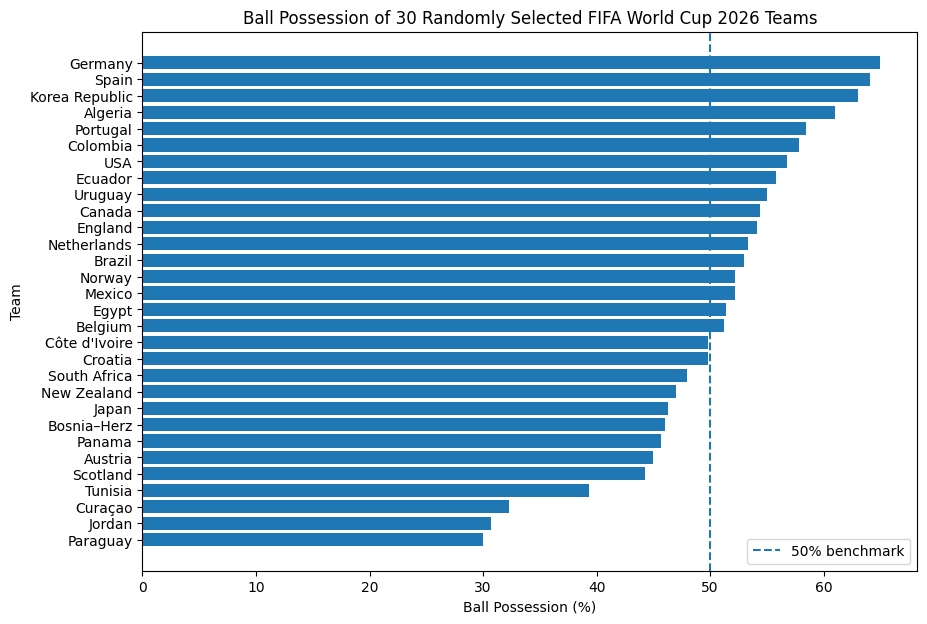

In [9]:
sorted_sample = sample.sort_values("Possession")

plt.figure(figsize=(10, 7))

plt.barh(
    sorted_sample["Team"],
    sorted_sample["Possession"]
)

plt.axvline(
    50,
    linestyle="--",
    label="50% benchmark"
)

plt.xlabel("Ball Possession (%)")
plt.ylabel("Team")
plt.title("Ball Possession of 30 Randomly Selected FIFA World Cup 2026 Teams")
plt.legend()

plt.show()

## Outlier Check

A boxplot was used to identify potential outliers. Two low possession values were identified. These observations were retained because they represent valid possession values rather than data-entry errors.

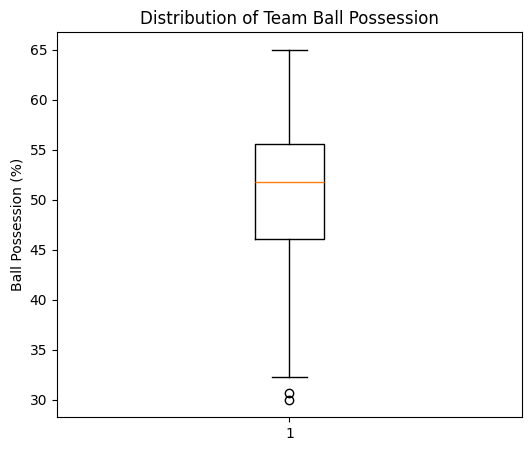

In [10]:
plt.figure(figsize=(6, 5))

plt.boxplot(sample["Possession"])

plt.ylabel("Ball Possession (%)")
plt.title("Distribution of Team Ball Possession")

plt.show()

## Normality Check

The Shapiro-Wilk test was used to assess whether there was significant evidence against the normality assumption required for the one-sample t-test.

In [11]:
stat, p = stats.shapiro(sample["Possession"])

print("Shapiro-Wilk statistic:", stat)
print("p-value:", p)

Shapiro-Wilk statistic: 0.9421992082553359
p-value: 0.10425705608455621


## 95% Confidence Interval

A 95% confidence interval was calculated to estimate a plausible range for the population mean ball possession.

In [12]:
confidence_level = 0.95
n = len(sample)
degrees_of_freedom = n - 1

t_critical = stats.t.ppf(
    (1 + confidence_level) / 2,
    degrees_of_freedom
)

margin_of_error = t_critical * (
    sample["Possession"].std() / (n ** 0.5)
)

lower = sample["Possession"].mean() - margin_of_error
upper = sample["Possession"].mean() + margin_of_error

print("Sample mean:", sample["Possession"].mean())
print("95% Confidence Interval:", lower, "to", upper)

Sample mean: 50.43
95% Confidence Interval: 47.081022913766965 to 53.778977086233034


## One-Sample t-Test

The one-sample t-test was used to determine whether the average ball possession was significantly different from the 50% benchmark.

H₀: μ = 50%

H₁: μ ≠ 50%

α = 0.05

In [13]:
t_statistic, p_value = stats.ttest_1samp(
    sample["Possession"],
    popmean=50
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 0.2626021986630777
p-value: 0.7947137939844064


## Final Conclusion

The sample mean ball possession was 50.43%.

The 95% confidence interval was 47.08% to 53.78%.

The one-sample t-test produced a t-statistic of 0.263 and a p-value of 0.795.

Since p > 0.05, the null hypothesis was not rejected.

Therefore, there was insufficient statistical evidence to conclude that the average ball possession of FIFA World Cup 2026 teams was significantly different from 50%.